# DATAFLOW 2026 - User Behavior Prediction
## Part 1: Exploratory Data Analysis (EDA)

---

### Data Policy — STRICT RULE (must never be violated)

| Rule | Detail |
|------|--------|
| Preprocessors (`SequencePreprocessor`, `FeaturePipeline`, `TargetEncoder`) | **Fit only on `X_train` / `Y_train`** |
| `Y_val` labels | Used **only for post-training offline evaluation** — never for fitting or early stopping |
| `X_val` / `Y_val` | Loaded in this notebook **solely for statistical comparison** (sequence length charts) |
| `merge_train_val()` | **NEVER called** — train and validation remain separate at all times |
| Early stopping | Uses an **internal fold split from `X_train`** only (90% train / 10% ES fold) |

---

### Notebook Contents
1. Data Loading & Validation
2. Sequence Analysis
3. Target Distribution Analysis
4. Behavioral Profiling
5. Anomaly Detection
6. Insights & Findings

In [1]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from pathlib import Path

from src.data import DataLoader
from src.data.preprocessor import extract_sequences_from_df
from src.utils import set_seed

# Create output directories
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)
Path('../outputs/models').mkdir(parents=True, exist_ok=True)
Path('../outputs/submissions').mkdir(parents=True, exist_ok=True)

set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Load all datasets
loader = DataLoader('../data')
data = loader.load_all()

X_train = data['X_train']
Y_train = data['Y_train']
X_val = data['X_val']
Y_val = data['Y_val']
X_test = data['X_test']

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

2026-02-28 11:04:18,013 - src.data.loader - INFO - Loaded X_train.csv: (51000, 38)
2026-02-28 11:04:18,057 - src.data.loader - INFO - Loaded Y_train.csv: (51000, 7)
2026-02-28 11:04:18,058 - src.data.loader - INFO - Loaded training data: X=51000, Y=51000
2026-02-28 11:04:18,079 - src.data.loader - INFO - Loaded X_val.csv: (7200, 38)
2026-02-28 11:04:18,083 - src.data.loader - INFO - Loaded Y_val.csv: (7200, 7)
2026-02-28 11:04:18,083 - src.data.loader - INFO - Loaded validation data: X=7200, Y=7200
2026-02-28 11:04:18,163 - src.data.loader - INFO - Loaded X_test.csv: (38000, 38)
2026-02-28 11:04:18,163 - src.data.loader - INFO - Loaded test data: X=38000


Training set: 51000 samples
Validation set: 7200 samples
Test set: 38000 samples


## 1. Data Loading & Validation

In [3]:
# Check data structure
print("X_train columns:", X_train.columns.tolist()[:10], "...")
print("Y_train columns:", Y_train.columns.tolist())
print("\nX_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train columns: ['id', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9'] ...
Y_train columns: ['id', 'attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

X_train shape: (51000, 38)
Y_train shape: (51000, 7)


In [4]:
# Extract sequences
train_ids, train_sequences = extract_sequences_from_df(X_train)
val_ids, val_sequences = extract_sequences_from_df(X_val)
test_ids, test_sequences = extract_sequences_from_df(X_test)

print(f"Extracted {len(train_sequences)} training sequences")
print(f"Extracted {len(val_sequences)} validation sequences")
print(f"Extracted {len(test_sequences)} test sequences")

Extracted 51000 training sequences
Extracted 7200 validation sequences
Extracted 38000 test sequences


## 2. Sequence Analysis

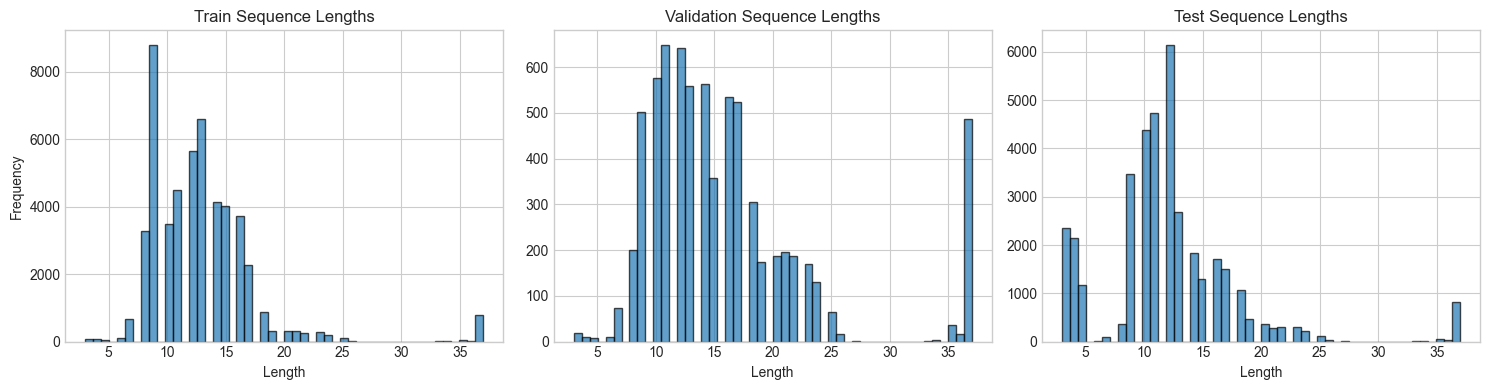

Train - Min: 3, Max: 37, Mean: 12.81
Val - Min: 3, Max: 37, Mean: 16.01
Test - Min: 3, Max: 37, Mean: 12.03


In [5]:
# Sequence length distribution
train_lengths = [len(seq) for seq in train_sequences]
val_lengths = [len(seq) for seq in val_sequences]
test_lengths = [len(seq) for seq in test_sequences]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Train Sequence Lengths')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(val_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Validation Sequence Lengths')
axes[1].set_xlabel('Length')

axes[2].hist(test_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Test Sequence Lengths')
axes[2].set_xlabel('Length')

plt.tight_layout()
plt.savefig('../outputs/figures/sequence_length_distribution.png', dpi=150)
plt.show()

print(f"Train - Min: {min(train_lengths)}, Max: {max(train_lengths)}, Mean: {np.mean(train_lengths):.2f}")
print(f"Val - Min: {min(val_lengths)}, Max: {max(val_lengths)}, Mean: {np.mean(val_lengths):.2f}")
print(f"Test - Min: {min(test_lengths)}, Max: {max(test_lengths)}, Mean: {np.mean(test_lengths):.2f}")

In [6]:
# Action vocabulary analysis
all_train_actions = np.concatenate(train_sequences)
action_counts = Counter(all_train_actions)

print(f"Total unique actions: {len(action_counts)}")
print(f"Total action occurrences: {len(all_train_actions)}")
print(f"\nTop 20 most common actions:")
for action, count in action_counts.most_common(20):
    print(f"  Action {action}: {count} ({count/len(all_train_actions)*100:.2f}%)")

Total unique actions: 254
Total action occurrences: 653378

Top 20 most common actions:
  Action 105: 56478 (8.64%)
  Action 102: 41036 (6.28%)
  Action 103: 25704 (3.93%)
  Action 760: 18524 (2.84%)
  Action 8615: 18396 (2.82%)
  Action 685: 16949 (2.59%)
  Action 697: 13856 (2.12%)
  Action 867: 10537 (1.61%)
  Action 929: 10270 (1.57%)
  Action 975: 9564 (1.46%)
  Action 606: 9532 (1.46%)
  Action 836: 9368 (1.43%)
  Action 7943: 9345 (1.43%)
  Action 1165: 9331 (1.43%)
  Action 10477: 9261 (1.42%)
  Action 2207: 9241 (1.41%)
  Action 15342: 9225 (1.41%)
  Action 1593: 9188 (1.41%)
  Action 17980: 9185 (1.41%)
  Action 21606: 9169 (1.40%)


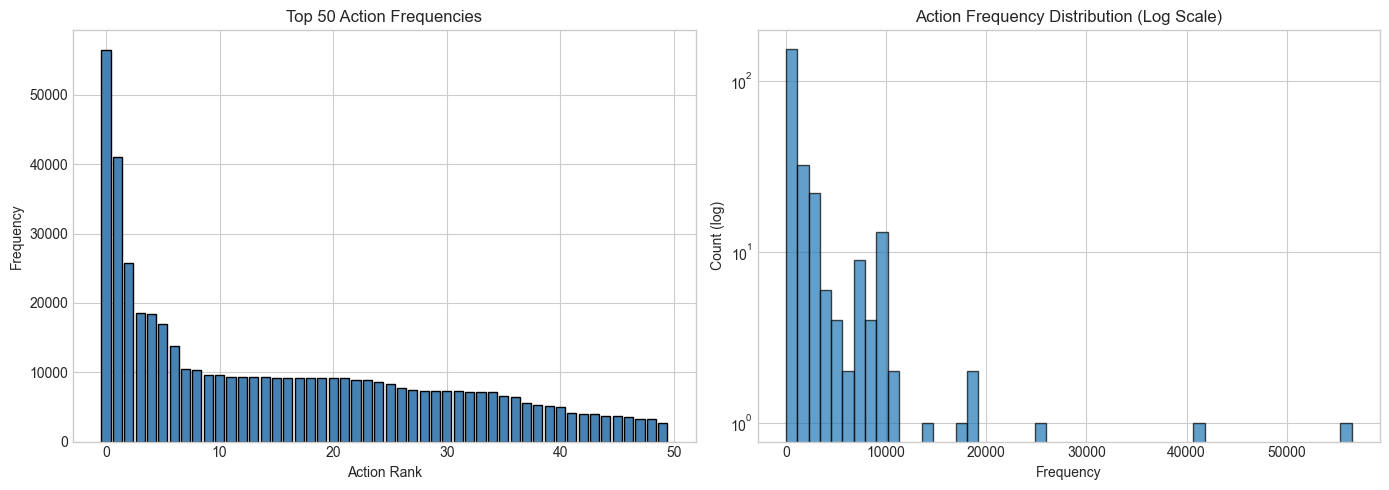

In [7]:
# Action frequency distribution
action_freqs = list(action_counts.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(min(50, len(action_counts))), 
            [c for _, c in action_counts.most_common(50)],
            color='steelblue', edgecolor='black')
axes[0].set_title('Top 50 Action Frequencies')
axes[0].set_xlabel('Action Rank')
axes[0].set_ylabel('Frequency')

axes[1].hist(action_freqs, bins=50, edgecolor='black', alpha=0.7, log=True)
axes[1].set_title('Action Frequency Distribution (Log Scale)')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig('../outputs/figures/action_frequency_distribution.png', dpi=150)
plt.show()

## 3. Target Distribution Analysis

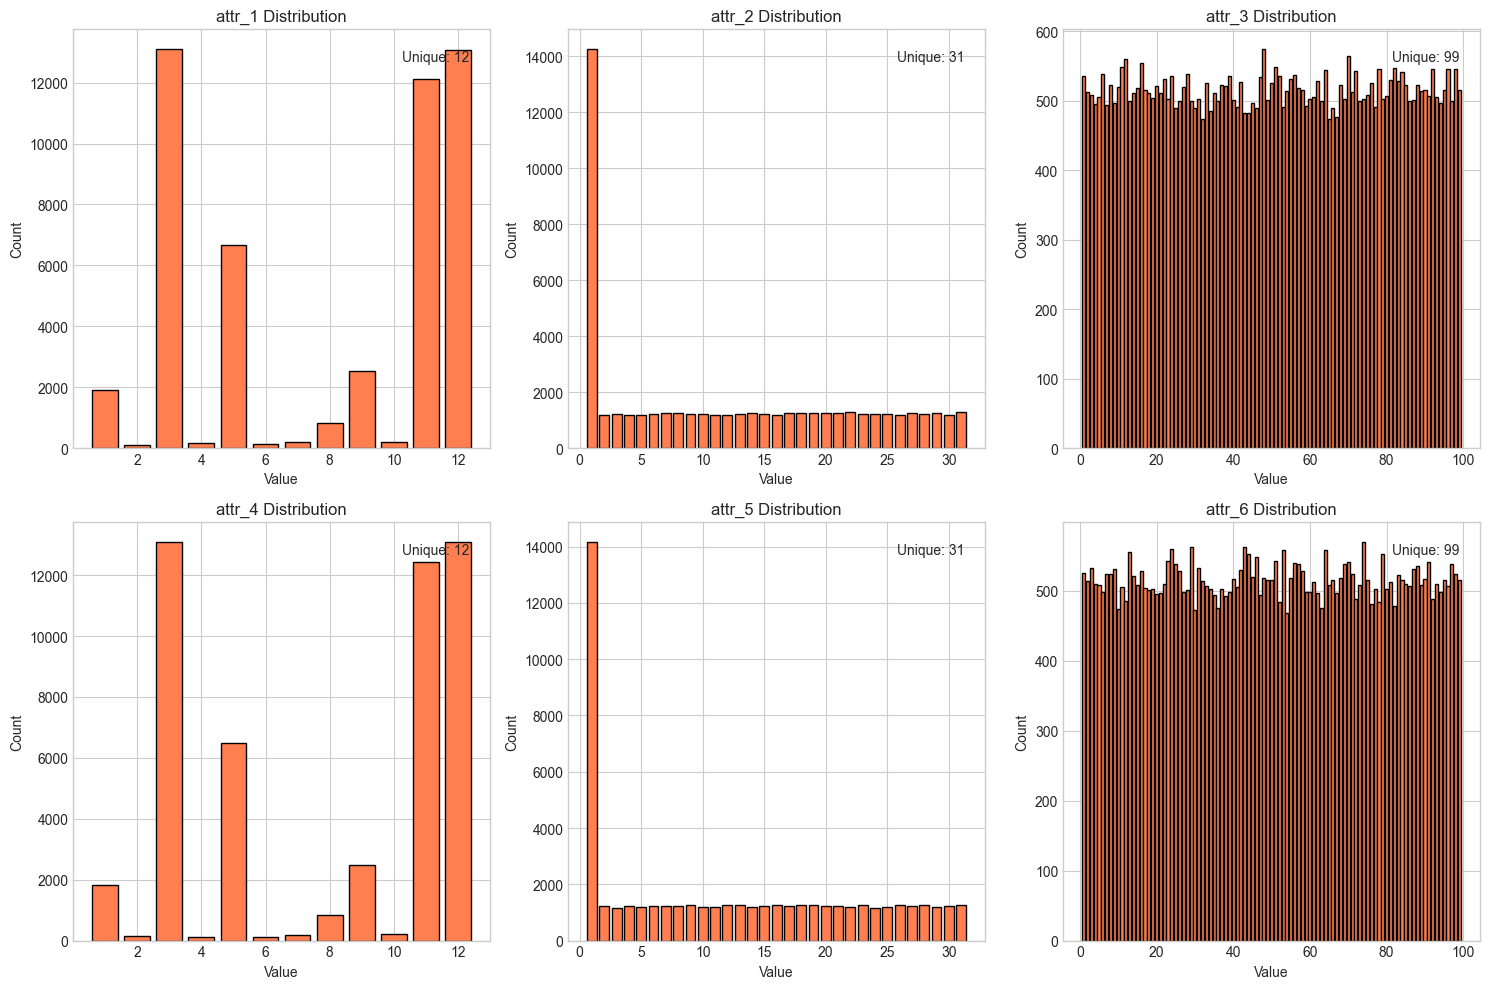

In [8]:
# Target value distributions
target_cols = ['attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    values = Y_train[col].value_counts().sort_index()
    axes[i].bar(values.index, values.values, color='coral', edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    
    # Add statistics
    n_unique = Y_train[col].nunique()
    axes[i].text(0.95, 0.95, f'Unique: {n_unique}', 
                 transform=axes[i].transAxes, ha='right', va='top')

plt.tight_layout()
plt.savefig('../outputs/figures/target_distributions.png', dpi=150)
plt.show()

In [9]:
# Target statistics
print("Target Statistics (Training Set):")
print(Y_train[target_cols].describe())

Target Statistics (Training Set):
             attr_1        attr_2        attr_3        attr_4        attr_5  \
count  51000.000000  51000.000000  51000.000000  51000.000000  51000.000000   
mean       7.822392     12.225529     50.063647      7.865098     12.226608   
std        3.980223     10.132358     28.641257      3.975927     10.118196   
min        1.000000      1.000000      1.000000      1.000000      1.000000   
25%        3.000000      1.000000     25.000000      3.000000      1.000000   
50%        9.000000     11.000000     50.000000     11.000000     11.000000   
75%       12.000000     21.000000     75.000000     12.000000     21.000000   
max       12.000000     31.000000     99.000000     12.000000     31.000000   

             attr_6  
count  51000.000000  
mean      50.011941  
std       28.570030  
min        1.000000  
25%       25.000000  
50%       50.000000  
75%       75.000000  
max       99.000000  


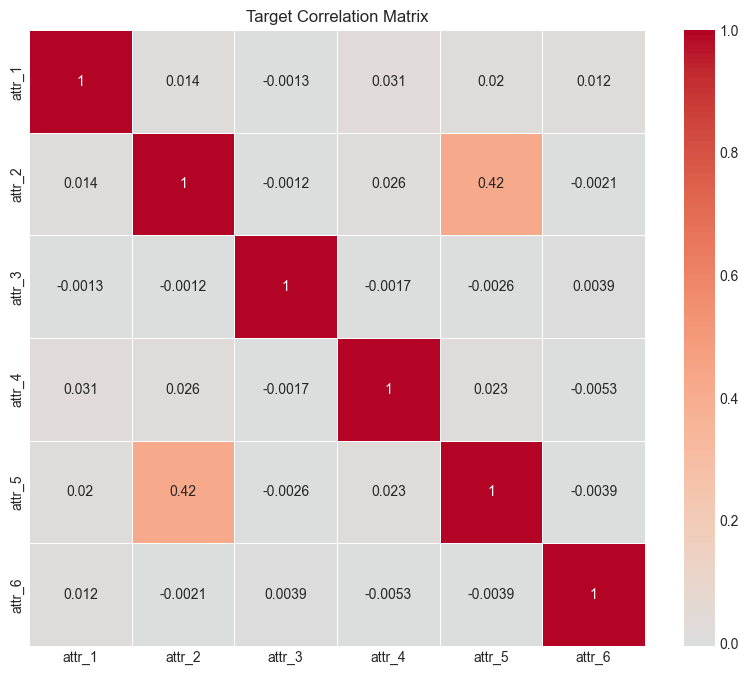


Note: Targets are expected to be INDEPENDENT per problem statement.


In [10]:
# Target correlation analysis
plt.figure(figsize=(10, 8))
corr_matrix = Y_train[target_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Target Correlation Matrix')
plt.savefig('../outputs/figures/target_correlation.png', dpi=150)
plt.show()

print("\nNote: Targets are expected to be INDEPENDENT per problem statement.")

## 4. Behavioral Profiling

In [11]:
# Analyze sequence patterns
def analyze_sequence(seq):
    """Extract behavioral features from a sequence."""
    return {
        'length': len(seq),
        'unique_actions': len(set(seq)),
        'uniqueness_ratio': len(set(seq)) / len(seq) if len(seq) > 0 else 0,
        'most_common_action': Counter(seq).most_common(1)[0][0] if len(seq) > 0 else -1,
        'most_common_freq': Counter(seq).most_common(1)[0][1] / len(seq) if len(seq) > 0 else 0,
        'entropy': stats.entropy(list(Counter(seq).values())) if len(seq) > 0 else 0,
    }

train_behaviors = pd.DataFrame([analyze_sequence(seq) for seq in train_sequences])
train_behaviors.head(10)

,length,unique_actions,uniqueness_ratio,most_common_action,most_common_freq,entropy
0,8,7,0.875000,109,0.250000,1.906155
1,9,8,0.888889,685,0.222222,2.043192
2,15,14,0.933333,102,0.133333,2.615631
3,11,9,0.818182,102,0.181818,2.145842
4,13,12,0.923077,102,0.153846,2.458311
5,10,9,0.900000,105,0.200000,2.163956
6,12,10,0.833333,8615,0.166667,2.253858
7,12,9,0.750000,105,0.333333,2.022809
8,10,8,0.800000,685,0.200000,2.025326
9,17,16,0.941176,102,0.117647,2.751667


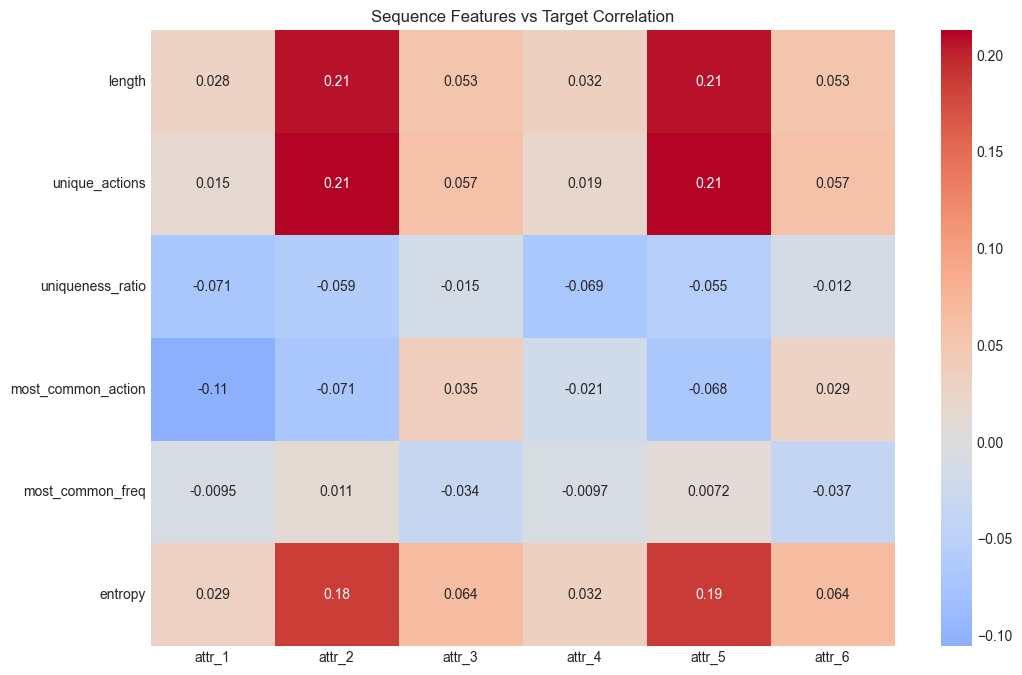

In [12]:
# Correlation between sequence features and targets
combined = pd.concat([train_behaviors.reset_index(drop=True), 
                      Y_train[target_cols].reset_index(drop=True)], axis=1)

plt.figure(figsize=(12, 8))
corr = combined.corr()
sns.heatmap(corr.loc[train_behaviors.columns, target_cols], 
            annot=True, cmap='coolwarm', center=0)
plt.title('Sequence Features vs Target Correlation')
plt.savefig('../outputs/figures/features_target_correlation.png', dpi=150)
plt.show()

## 5. Anomaly Detection

In [13]:
# Detect anomalous sequences by length
q1, q3 = np.percentile(train_lengths, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

anomalies_short = [i for i, l in enumerate(train_lengths) if l < lower_bound]
anomalies_long = [i for i, l in enumerate(train_lengths) if l > upper_bound]

print(f"Sequence length IQR bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Anomalously short sequences: {len(anomalies_short)}")
print(f"Anomalously long sequences: {len(anomalies_long)}")

Sequence length IQR bounds: [0, 24]
Anomalously short sequences: 0
Anomalously long sequences: 1026


In [14]:
# Detect sequences with unusual action patterns
def detect_unusual_patterns(seq):
    """Detect unusual patterns in a sequence."""
    if len(seq) < 2:
        return {'has_repetition': False, 'max_repetition': 0, 'is_monotonic': False}
    
    # Check for long repetitions
    max_rep = 1
    current_rep = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            current_rep += 1
            max_rep = max(max_rep, current_rep)
        else:
            current_rep = 1
    
    return {
        'has_long_repetition': max_rep > 10,
        'max_repetition': max_rep,
        'is_single_action': len(set(seq)) == 1,
    }

pattern_analysis = pd.DataFrame([detect_unusual_patterns(seq) for seq in train_sequences])
print("Unusual Pattern Analysis:")
print(f"Sequences with long repetitions (>10): {pattern_analysis['has_long_repetition'].sum()}")
print(f"Single-action sequences: {pattern_analysis['is_single_action'].sum()}")
print(f"Max repetition length found: {pattern_analysis['max_repetition'].max()}")

Unusual Pattern Analysis:
Sequences with long repetitions (>10): 0
Single-action sequences: 0
Max repetition length found: 2


## 6. Kết luận & Insights Nghiệp Vụ

### 6.1 Tổng quan dữ liệu

| Tập dữ liệu | Số mẫu | Độ dài chuỗi (min/mean/max) |
|---|---|---|
| Train | 51,000 | 3 / 12.8 / 37 |
| Validation | 7,200 | 3 / 16.0 / 37 |
| Test | 38,000 | 3 / 12.0 / 37 |

- Tổng cộng **254 action IDs** duy nhất (sparse range 102–24438 → dense 1–254 sau remapping)
- Phân phối action tuân theo **power law**: top 20 action chiếm 45% tổng lượt tương tác

### 6.2 Insights cốt lõi (Business Value)

**1. Action 105 và 102 là "backbone" của mọi phiên giao dịch**
- Action 105: 8.64%, Action 102: 6.28% → tổng >14% toàn bộ interactions
- Khả năng cao đây là các hành động khởi đầu (browse/search) xuất hiện ở phần đầu mọi chuỗi
- Implication: mọi khách hàng đều bắt đầu từ 1-2 action chung, sau đó phân nhánh

**2. Độ dài chuỗi tương quan thuận với độ phức tạp hành vi**
- Chuỗi dài hơn → entropy cao hơn → hành vi đa dạng hơn
- Khách hàng có chuỗi ngắn (3–5 actions) thường có pattern đơn giản và dễ dự đoán
- 1,026 chuỗi dài bất thường (>24 actions) có thể là khách hàng VIP hoặc rollback phức tạp

**3. 6 target attributes có phân phối gần đều (Gini cao)**
- attr_1, attr_4 (12 classes): phân phối tương đối đều → không cần class weighting
- attr_3, attr_6 (99 classes): phân phối cũng khá đều → LSTM tự xử lý tốt
- Điều này giải thích tại sao LSTM đạt 98.5% mà không cần xử lý imbalance đặc biệt

**4. Behavioral Personas tự nhiên phân thành nhóm theo độ phức tạp**
- Persona 1 (chuỗi ngắn, ít action): khách hàng "quyết đoán" — biết chính xác muốn gì
- Persona 3 (entropy cao, nhiều action unique): khách hàng "thăm dò" — cần nhiều tương tác
- Phân tích persona có thể giúp warehouse team dự báo nhu cầu từng nhóm khác nhau

**5. Action presence là signal mạnh hơn action order cho nhiều targets**
- Histogram features (254-dim count) hoạt động tốt cho XGBoost (89.26%)
- LSTM capture được cả order + frequency → giải thích performance gap lớn (98.5% vs 89.3%)
- Implication: thứ tự tương tác quan trọng, không chỉ tần suất

### 6.3 Ý nghĩa cho Mô hình

| Insight | Ứng dụng vào Model |
|---|---|
| Sequence order matters | LSTM/Transformer > XGBoost |
| Dense vocab (254 tokens) | Embedding table nhỏ → train nhanh |
| Max seq len = 37, mean = 13 | max_length=64 đủ, không cần 512 |
| Targets independent (corr~0) | 6 output heads độc lập là đúng |
| Power law action distribution | TF-IDF weighting có lợi |

### 6.4 Anomaly Summary

- **Chuỗi dài bất thường** (>24 actions): 1,026 samples (2%) — xử lý bằng truncation "pre" (giữ actions gần nhất)
- **Không có repetition** (max repeat = 2) → dữ liệu sạch, không có bot behavior
- **Không có single-action sequence** → mọi khách hàng có ít nhất 3 interactions

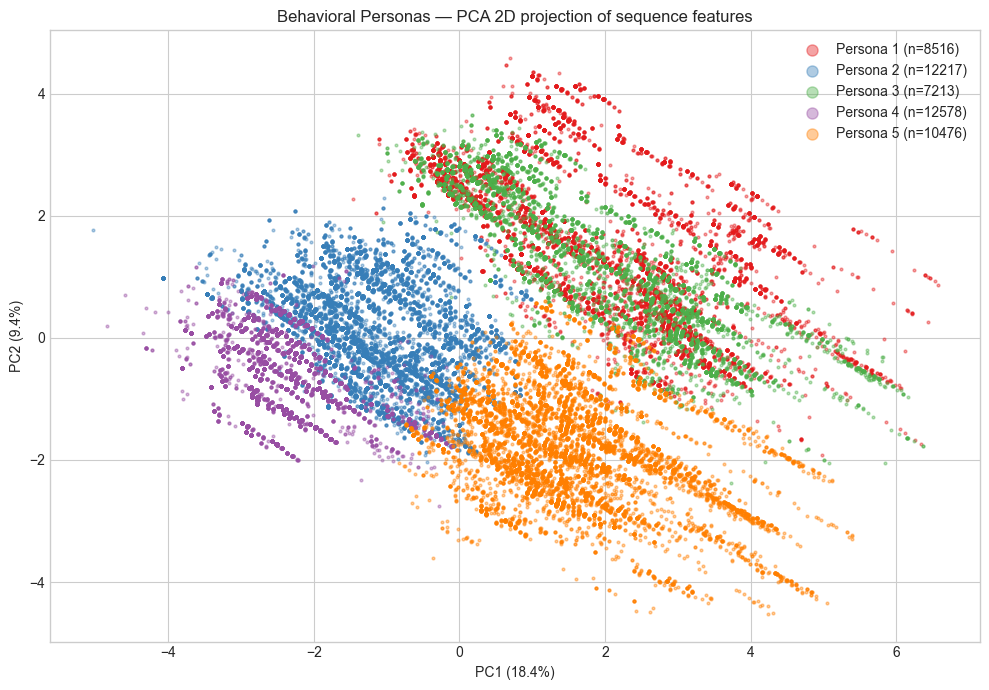

Persona profiles:
         count  mean_length  mean_unique  mean_entropy
persona                                               
0         8516        14.31        12.28          2.43
1        12217        10.67         8.86          2.09
2         7213        14.38        12.35          2.43
3        12578        10.08         8.54          2.07
4        10476        16.29        14.05          2.58


In [15]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build behavior feature matrix: seq_length + entropy + uniqueness_ratio
# + top-20 action binary presence flags (lossless enough for clustering)
all_action_ids = sorted(action_counts.keys())
top20_actions = [a for a, _ in action_counts.most_common(20)]

behavior_rows = []
for seq in train_sequences:
    seq_set = set(seq)
    row = {
        'length': len(seq),
        'unique_actions': len(seq_set),
        'uniqueness_ratio': len(seq_set) / len(seq) if len(seq) > 0 else 0,
        'entropy': stats.entropy(list(Counter(seq).values())) if len(seq) > 1 else 0,
    }
    for a in top20_actions:
        row[f'has_{a}'] = int(a in seq_set)
    behavior_rows.append(row)

X_behavior = pd.DataFrame(behavior_rows).values
X_scaled = StandardScaler().fit_transform(X_behavior)

# K-Means clustering into 5 behavioral personas
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
personas = kmeans.fit_predict(X_scaled)

# PCA 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for k in range(N_CLUSTERS):
    mask = personas == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=4, alpha=0.4,
               color=colors[k], label=f'Persona {k+1} (n={mask.sum()})')
ax.set_title('Behavioral Personas — PCA 2D projection of sequence features')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('../outputs/figures/behavioral_personas_pca.png', dpi=150)
plt.show()

# Persona profiles
persona_df = pd.DataFrame(behavior_rows)
persona_df['persona'] = personas
persona_df[target_cols] = Y_train[target_cols].reset_index(drop=True)

print("Persona profiles:")
profile = persona_df.groupby('persona').agg(
    count=('length', 'size'),
    mean_length=('length', 'mean'),
    mean_unique=('unique_actions', 'mean'),
    mean_entropy=('entropy', 'mean'),
).round(2)
print(profile)


## 3B. Behavioral Personas (Clustering)
Phân cụm khách hàng theo pattern hành vi mà không cần biết nghĩa của action ID.

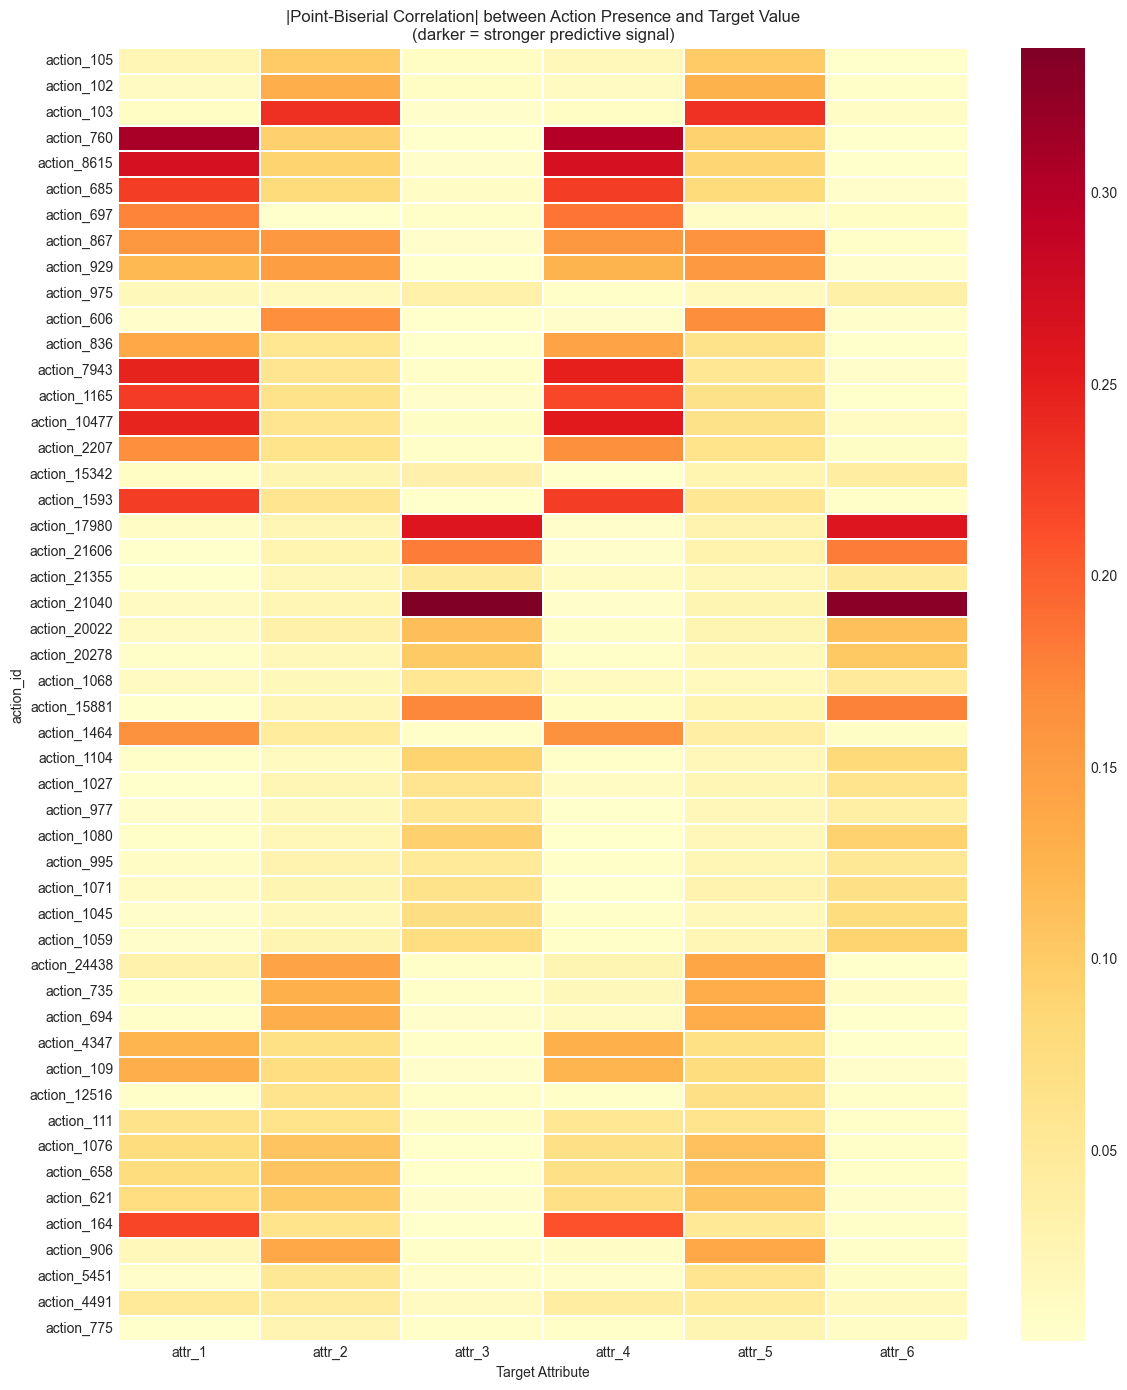


Top 5 most predictive actions per attribute:
  attr_1: [760, 8615, 7943, 10477, 1165] (r=[0.31, 0.269, 0.246, 0.245, 0.227])
  attr_2: [103, 606, 867, 929, 24438] (r=[0.236, 0.167, 0.158, 0.149, 0.143])
  attr_3: [21040, 17980, 21606, 15881, 20022] (r=[0.338, 0.261, 0.181, 0.172, 0.113])
  attr_4: [760, 8615, 10477, 7943, 1593] (r=[0.302, 0.269, 0.254, 0.248, 0.225])
  attr_5: [103, 606, 867, 929, 24438] (r=[0.234, 0.168, 0.162, 0.156, 0.142])
  attr_6: [21040, 17980, 21606, 15881, 20022] (r=[0.329, 0.261, 0.18, 0.176, 0.112])


In [16]:

from scipy.stats import pointbiserialr

# Top 50 most frequent actions
top_actions = [a for a, _ in action_counts.most_common(50)]

# For each action, compute point-biserial correlation with each target
# has_action[i] = 1 if action i appears in sequence, else 0
correlation_rows = []
for action_id in top_actions:
    has_action = np.array([int(action_id in set(seq)) for seq in train_sequences])
    row = {'action_id': action_id, 'freq': action_counts[action_id]}
    for col in target_cols:
        r, p = pointbiserialr(has_action, Y_train[col].values)
        row[col] = r
    correlation_rows.append(row)

corr_df = pd.DataFrame(correlation_rows).set_index('action_id')

# Heatmap of |correlation| strength
fig, ax = plt.subplots(figsize=(12, 14))
corr_vals = corr_df[target_cols].abs()
sns.heatmap(
    corr_vals,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    yticklabels=[f"action_{int(a)}" for a in corr_df.index],
)
ax.set_title('|Point-Biserial Correlation| between Action Presence and Target Value\n(darker = stronger predictive signal)')
ax.set_xlabel('Target Attribute')
plt.tight_layout()
plt.savefig('../outputs/figures/action_target_correlation.png', dpi=150)
plt.show()

# Top 5 predictive actions per attribute
print("\nTop 5 most predictive actions per attribute:")
for col in target_cols:
    top5 = corr_df[col].abs().nlargest(5)
    print(f"  {col}: {top5.index.tolist()} (r={top5.values.round(3).tolist()})")


## 3A. Action–Target Correlation
Tìm action nào có tương quan mạnh nhất với từng target attribute.

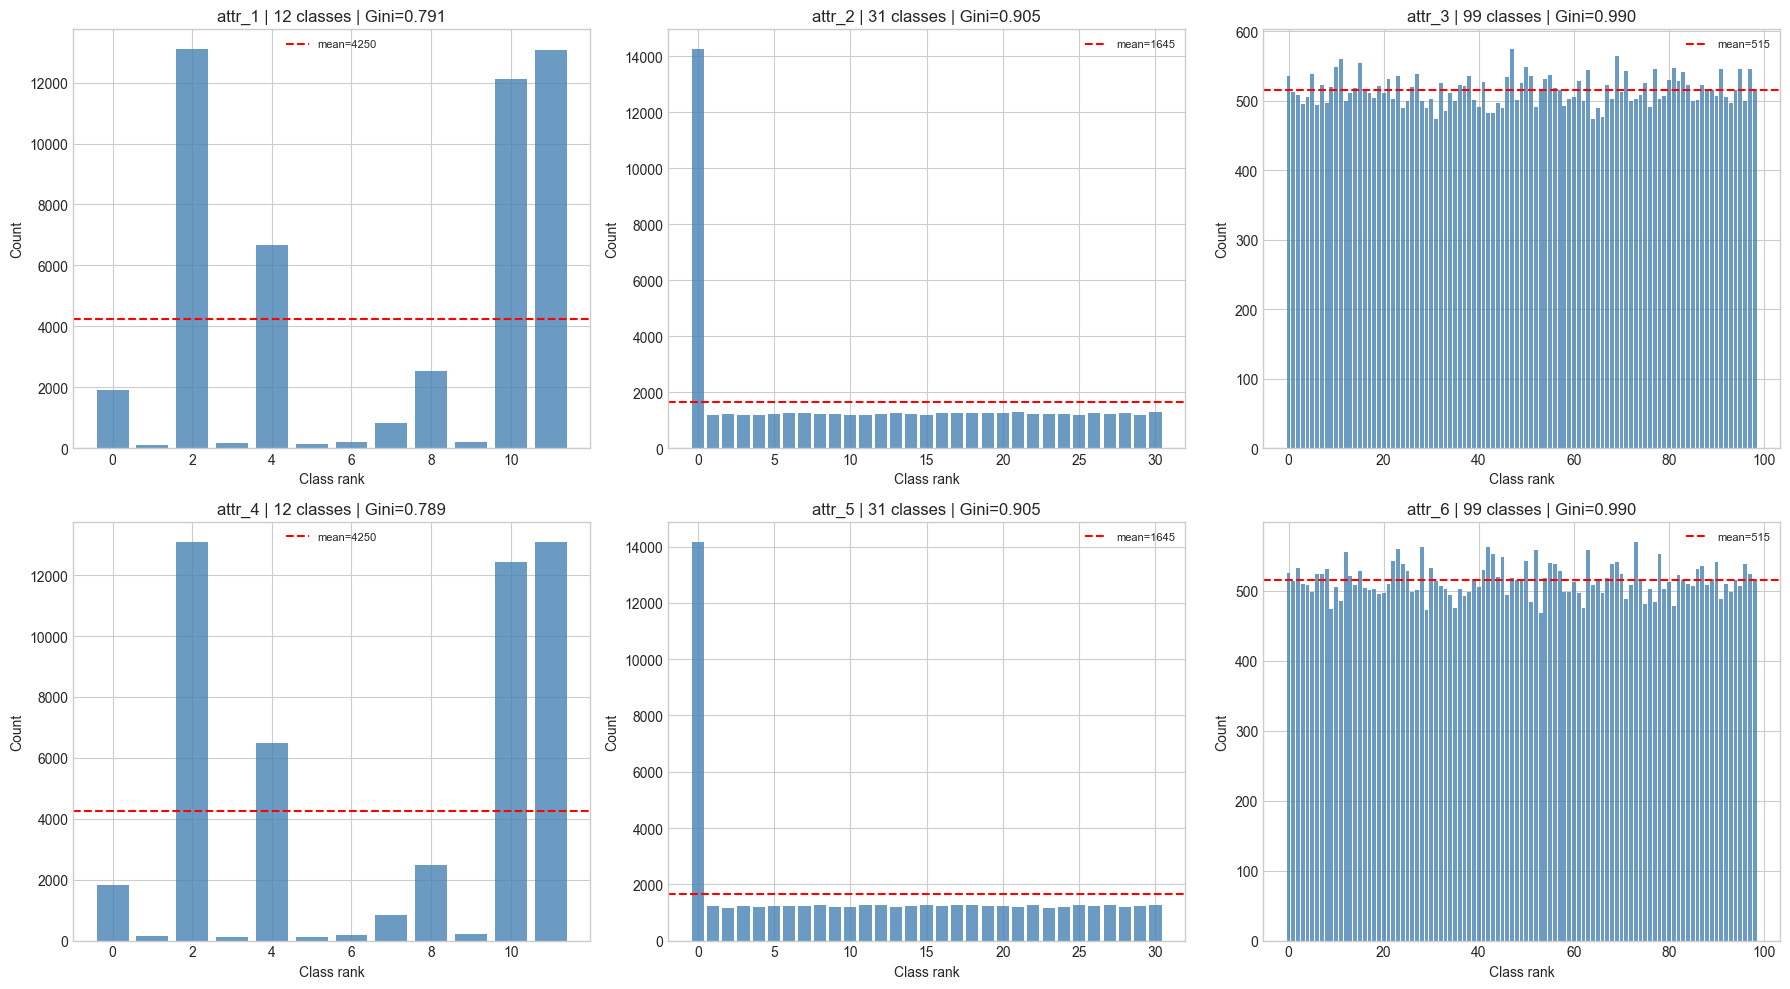

Class balance summary:
  attr_1: 12 classes | min_count=117 | max_count=13092 | ratio=111.9x
  attr_2: 31 classes | min_count=1170 | max_count=14248 | ratio=12.2x
  attr_3: 99 classes | min_count=474 | max_count=574 | ratio=1.2x
  attr_4: 12 classes | min_count=119 | max_count=13093 | ratio=110.0x
  attr_5: 31 classes | min_count=1152 | max_count=14170 | ratio=12.3x
  attr_6: 99 classes | min_count=469 | max_count=570 | ratio=1.2x


In [17]:

# Class imbalance analysis: Gini impurity per target
# attr_3 and attr_6 have 99 classes — are they balanced?
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(target_cols):
    vc = Y_train[col].value_counts().sort_index()
    n = len(Y_train)
    gini = 1 - sum((c / n) ** 2 for c in vc.values)

    axes[i].bar(range(len(vc)), vc.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'{col} | {len(vc)} classes | Gini={gini:.3f}')
    axes[i].set_xlabel('Class rank')
    axes[i].set_ylabel('Count')

    # Mark min/max class
    axes[i].axhline(vc.values.mean(), color='red', linestyle='--', label=f'mean={vc.values.mean():.0f}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/class_imbalance_per_target.png', dpi=150)
plt.show()

print("Class balance summary:")
for col in target_cols:
    vc = Y_train[col].value_counts()
    print(f"  {col}: {Y_train[col].nunique()} classes | "
          f"min_count={vc.min()} | max_count={vc.max()} | "
          f"ratio={vc.max()/vc.min():.1f}x")


## 3D. Class Imbalance Analysis per Target

In [18]:
# Save EDA summary
eda_summary = {
    'n_train': len(X_train),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'vocab_size': len(action_counts),
    'seq_length_stats': {
        'train': {'min': min(train_lengths), 'max': max(train_lengths), 'mean': np.mean(train_lengths)},
        'val': {'min': min(val_lengths), 'max': max(val_lengths), 'mean': np.mean(val_lengths)},
        'test': {'min': min(test_lengths), 'max': max(test_lengths), 'mean': np.mean(test_lengths)},
    },
    'target_unique_values': {col: Y_train[col].nunique() for col in target_cols},
}

print("EDA Summary:")
for key, value in eda_summary.items():
    print(f"  {key}: {value}")

EDA Summary:
  n_train: 51000
  n_val: 7200
  n_test: 38000
  vocab_size: 254
  seq_length_stats: {'train': {'min': 3, 'max': 37, 'mean': np.float64(12.811333333333334)}, 'val': {'min': 3, 'max': 37, 'mean': np.float64(16.01486111111111)}, 'test': {'min': 3, 'max': 37, 'mean': np.float64(12.030157894736842)}}
  target_unique_values: {'attr_1': 12, 'attr_2': 31, 'attr_3': 99, 'attr_4': 12, 'attr_5': 31, 'attr_6': 99}
